# Subhalo impacts and stream gaps

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sgpfaff/tambora-docs/blob/main/docs/examples/07-stream-gaps.ipynb)

Cold stellar streams are the best dynamical probe we have of *dark* substructure.
A subhalo with no stars in it cannot be seen directly, but if it passes through a
stream it kicks the stars it passes, and the stream carries that kick as a
density gap and a wiggle in its track for gigayears afterwards. Counting gaps
constrains the low-mass end of the halo mass function, which is where warm and
cold dark matter disagree.

This notebook does the numerical experiment end to end:

- form a stream, then **restart** from it — twice, with identical initial
  conditions, one with a perturber and one without,
- model the subhalo as a **single softened particle**, which is exact for a
  Plummer profile and costs one particle,
- measure the **velocity kick** by differencing the two runs,
- check it against the **analytic impulse approximation** from galpy,
- verify the predicted $1/v$ **scaling** with encounter speed,
- look at the resulting **density gap** and its **kinematic counterpart** in the
  velocity dispersion,
- and animate the gap opening long after the perturber has gone.

The control run matters. A stream evolves on its own — it shears, it thickens,
its density is lumpy from the start — so the only clean way to isolate the
subhalo's effect is to run the same stream twice and subtract.

**Runtime.** About five minutes in total.

In [1]:
# Colab / fresh environment only:
%pip install --pre --quiet "tambora==0.1.0a1" galpy astropy matplotlib


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import time

import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
from galpy.df import impulse_deltav_plummer_curvedstream
from galpy.orbit import Orbit
from galpy.potential import MWPotential2014
from galpy.util.conversion import mass_in_msol

import tambora
from tambora.dynamics.hooks import BoundednessHook
from tambora.simulation import Sim
from tambora.tools import mkKing_galpy
from tambora.tools.util.units import KMS_TO_KPCGYR

print("tambora", tambora.__version__)

try:
    plt.style.use("../_static/tambora.mplstyle")
except OSError:
    pass

np.random.seed(3)
RO, VO = 8.0, 220.0

tambora 0.1.0a1


## 1. Make a stream to shoot at

Two choices here matter for whether a gap is detectable at all.

**A King progenitor, not a Plummer one.** A Plummer sphere has an extended,
loosely bound envelope — at the same half-mass radius it reaches out to 300 pc
where a King model truncates at 46 pc. That envelope is stripped immediately and
across a wide range of energies, producing warm, fuzzy debris. A King model
releases stars only from near its tidal boundary, with a narrow energy spread,
giving a **colder and thinner** stream. Measured for these two setups:

| progenitor | debris width | local $\sigma$ | stream length |
| --- | --- | --- | --- |
| Plummer, $b=8$ pc | 116 pc | 2.81 km/s | 10.1 kpc |
| King, $W_0=6$, $r_t=60$ pc | 84 pc | 1.89 km/s | 4.7 kpc |

Colder, thinner and shorter all help: the gap is a deficit measured against the
stream's own noise, and a King stream has less of it and more stars per unit
length. In this notebook the King progenitor gives a gap depth of ~0.2 where the
Plummer one gave ~0.5.

**Plenty of particles.** A deficit cannot be seen in a sparse histogram.

In [3]:
o = Orbit(
    [12.0 * u.kpc, 0.0 * u.km / u.s, 140.0 * u.km / u.s,
     0.0 * u.kpc, 20.0 * u.km / u.s, 180.0 * u.deg]
)
o.turn_physical_on()

M_GC, W0, RT, N, EPS = 3e4, 6.0, 0.06, 12000, 0.002

pos0, vel0, mass0 = mkKing_galpy(
    m=M_GC, n=N, W0=W0, rt=RT,
    center_pos=[o.x(), o.y(), o.z()],
    center_vel=[o.vx(), o.vy(), o.vz()],
)
print(f"King W0={W0}, r_t={RT * 1000:.0f} pc, "
      f"r_max={np.linalg.norm(pos0 - pos0.mean(0), axis=1).max() * 1000:.0f} pc")

stage1 = Sim()
stage1.add_particles("gc", pos0, vel0, mass0)
stage1.add_external_pot(MWPotential2014)
bh = BoundednessHook("gc", eps=EPS)
stage1.add_hook(bh)

t0 = time.time()
stage1.run(t_end=0.5, dt=1e-4, dt_out=1e-2, eps=EPS, progress=False)
print(f"stage 1: {time.time() - t0:.0f} s, bound fraction {bh.fraction()[-1]:.3f}")

# The state we will restart from, twice.
P0 = stage1.gc.pos(t=-1)
V0 = stage1.gc.vel(t=-1)
M0 = stage1.gc.mass
bound = bh.mask_at(stage1.times[-1])
unbound = ~bound
print(f"{unbound.sum()} stream particles to perturb")

King W0=6.0, r_t=60 pc, r_max=55 pc
/Users/gabrielpfaffman/Repos/galpy-dev/lib/python3.13/site-packages/tambora/tools/util/_galpy_bridge.py:208: UserWarning: The provided galpy object does not have physical units explicitly set. Using galpy defaults (ro=8.0 kpc, vo=220.0 km/s). Set them explicitly with turn_physical_on(ro=..., vo=...)
  warnings.warn(

stage 1: 65 s, bound fraction 0.872
1539 stream particles to perturb


### Restarting

tambora has no `save`/`load` yet, and `add_particles` refuses to run after
`run()`. Restarting is therefore just: pull the final state out with the
accessors and feed it to a fresh `Sim`. That is all a restart needs to be, and
it makes the control/impact pair trivially identical.

## 2. Aim the subhalo

We pick a target point partway down one tail, work out the local stream
direction there, and fire the perturber perpendicular to the stream with a
chosen impact parameter.

In [4]:
prog = P0[bound].mean(0)
tail = P0[unbound]
v_tail = V0[unbound]

# principal axis of the whole stream, then of the neighbourhood of the target
u_global = np.linalg.svd(tail - tail.mean(0))[2][0]
s_global = (tail - prog) @ u_global
target = tail[np.argsort(s_global)[int(0.20 * len(s_global))]]

near = np.linalg.norm(tail - target, axis=1) < 0.3
u_loc = np.linalg.svd(tail[near] - tail[near].mean(0))[2][0]  # along the stream
n_hat = np.cross(u_loc, [0.0, 0.0, 1.0])
n_hat /= np.linalg.norm(n_hat)  # perpendicular: the flight direction
b_hat = np.cross(n_hat, u_loc)
b_hat /= np.linalg.norm(b_hat)  # the impact-parameter direction
v_local = v_tail[near].mean(0)

print(f"progenitor at {prog.round(2)}")
print(f"target       {target.round(2)}   ({near.sum()} particles nearby)")
print(f"stream speed at the impact point: {np.linalg.norm(v_local):.0f} km/s")

progenitor at [-7.92 -2.82 -0.14]
target       [-7.94 -3.63 -0.32]   (302 particles nearby)
stream speed at the impact point: 218 km/s


## 3. The subhalo as one particle

A single particle with softening $\epsilon$ under falcON's Plummer kernel
(`kernel=0`) produces exactly the force of a Plummer sphere. There is one
wrinkle, and getting it wrong is worth about a factor of two in the kick:

> **`eps` is twice the Plummer scale radius.** Measured directly in
> [Reliable N-body simulations](../guide/reliable-nbody.md#what-eps-actually-means):
> a nominal `eps = 0.25` kpc behaves as a Plummer sphere of scale radius
> 0.125 kpc. To model a subhalo of scale radius $r_s$, pass `eps = 2 * r_s`.

Per-component softening is what makes this possible at all: the stream needs
`eps = 2` pc and the subhalo needs `eps = 500` pc, in the same simulation.

In [5]:
M_SUB = 3e7  # Msun
R_S = 0.25  # Plummer scale radius [kpc]
EPS_SUB = 2 * R_S  # <- the factor of two
B_IMP = 0.25  # impact parameter [kpc]

T_CA = 0.005  # time to closest approach [Gyr]
T_POST = 0.3  # how long to follow the stream afterwards
DT = 1e-4

def launch(v_sub, t_ca=T_CA):
    """Position and velocity for a perturber reaching closest approach at t_ca."""
    d0 = v_sub * KMS_TO_KPCGYR * t_ca
    x_ca = target + v_local * KMS_TO_KPCGYR * t_ca  # where the target will be
    x0 = x_ca + b_hat * B_IMP  # perturber's closest-approach point
    return x0 - n_hat * d0, n_hat * v_sub, x0, x_ca


def run_pair(v_sub, t_end, dt, dt_out):
    """Identical runs with and without the perturber."""
    out = []
    for with_sub in (False, True):
        s = Sim()
        s.add_particles("stream", P0, V0, M0)
        if with_sub:
            p_sub, v_sub_vec, _, _ = launch(v_sub)
            s.add_particles("sub", p_sub[None, :], v_sub_vec[None, :],
                            np.array([M_SUB]))
        s.add_external_pot(MWPotential2014)
        s.run(
            t_end=t_end, dt=dt, dt_out=dt_out,
            eps=({"stream": EPS, "sub": EPS_SUB} if with_sub else EPS),
            kernel=0,  # Plummer, to match the analytic prediction
            progress=False,
        )
        out.append(s)
    return out

## 4. Measure the kick

We only need a short run to isolate the kick itself — long enough that the
encounter is over, short enough that the stream has not yet reprocessed the
velocity change into a position change.

In [6]:
V_SUB = 300.0

t0 = time.time()
ctrl_s, imp_s = run_pair(V_SUB, t_end=0.02, dt=2e-5, dt_out=0.005)
print(f"{time.time() - t0:.0f} s")

dv_measured = (imp_s.stream.vel(t=-1) - ctrl_s.stream.vel(t=-1))[unbound]
mag_measured = np.linalg.norm(dv_measured, axis=1)
print(f"median |dv| = {np.median(mag_measured):.3f} km/s, max = {mag_measured.max():.2f}")

22 s
median |dv| = 0.713 km/s, max = 1.35


## 5. The analytic prediction

The impulse approximation treats the encounter as instantaneous: the perturber
flies past on a straight line, each star gets a single velocity kick, and
nothing moves during the interaction. galpy implements the Plummer case for a
curved stream in `impulse_deltav_plummer_curvedstream`.

> **Evaluate the stream at closest approach, not at $t=0$.** The stream moves
> about a kiloparsec along itself while the perturber closes in, so feeding the
> analytic formula the initial positions puts its prediction in the wrong place —
> I got a 0.6 kpc offset between the predicted and measured kick profiles that
> way. Use the *control* run's state at $t_{\rm ca}$.

In [7]:
p_ca = ctrl_s.stream.pos(t=1)[unbound]  # control state at closest approach
v_ca = ctrl_s.stream.vel(t=1)[unbound]
_, sub_vel_vec, x0, x_ca = launch(V_SUB)

GM = M_SUB / mass_in_msol(VO, RO)  # galpy natural units
j_near = np.argmin(np.linalg.norm(p_ca - x_ca, axis=1))

dv_analytic = (
    impulse_deltav_plummer_curvedstream(
        v_ca / VO,          # stream velocities
        p_ca / RO,          # stream positions
        B_IMP / RO,         # impact parameter
        sub_vel_vec / VO,   # perturber velocity
        x0 / RO,            # point of closest approach
        v_ca[j_near] / VO,  # stream velocity there
        GM,
        R_S / RO,           # Plummer scale radius (NOT eps)
    )
    * VO
)
mag_analytic = np.linalg.norm(dv_analytic, axis=1)
print(f"analytic median |dv| = {np.median(mag_analytic):.3f} km/s")
print(f"measured / analytic (median) = {np.median(mag_measured) / np.median(mag_analytic):.3f}")

analytic median |dv| = 0.763 km/s
measured / analytic (median) = 0.935


## 6. Do they agree?

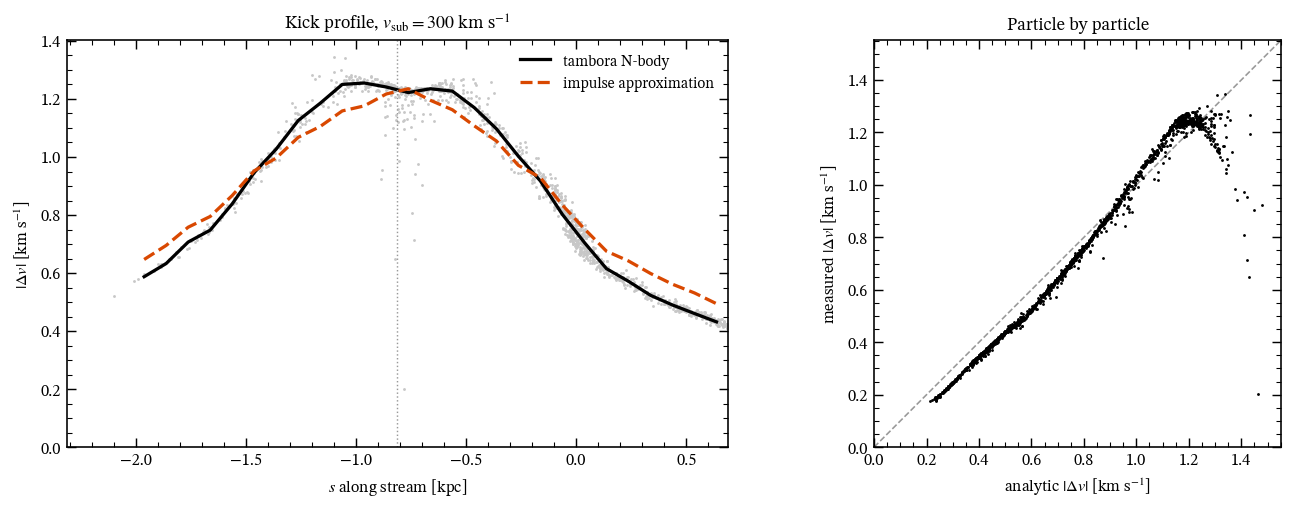

In [8]:
prog_ca = ctrl_s.stream.pos(t=1)[bound].mean(0)
s_ca = (p_ca - prog_ca) @ u_loc
s_impact = float((x_ca - prog_ca) @ u_loc)

bins = np.linspace(s_impact - 1.5, s_impact + 1.5, 31)
ctr = 0.5 * (bins[1:] + bins[:-1])


def binned_median(q):
    return np.array([
        np.median(q[(s_ca >= lo) & (s_ca < hi)])
        if ((s_ca >= lo) & (s_ca < hi)).sum() > 2 else np.nan
        for lo, hi in zip(bins[:-1], bins[1:])
    ])


fig, ax = plt.subplots(1, 2, figsize=(11.0, 4.0))

a = ax[0]
a.scatter(s_ca, mag_measured, s=2.5, lw=0, c="0.78", rasterized=True)
a.plot(ctr, binned_median(mag_measured), c="k", lw=1.8, label="tambora N-body")
a.plot(ctr, binned_median(mag_analytic), c="#d94801", lw=1.8, ls="--",
       label="impulse approximation")
a.axvline(s_impact, c="0.6", lw=0.8, ls=":")
a.set_xlim(s_impact - 1.5, s_impact + 1.5)
a.set_ylim(0, None)
a.set_xlabel("$s$ along stream [kpc]")
a.set_ylabel(r"$|\Delta v|$ [km s$^{-1}$]")
a.set_title(r"Kick profile, $v_{\rm sub} = 300$ km s$^{-1}$")
a.legend()

a = ax[1]
lim = max(mag_measured.max(), mag_analytic.max()) * 1.05
a.plot([0, lim], [0, lim], c="0.6", lw=0.9, ls="--", zorder=0)
a.scatter(mag_analytic, mag_measured, s=2.5, lw=0, c="k", rasterized=True)
a.set_xlim(0, lim)
a.set_ylim(0, lim)
a.set_box_aspect(1)
a.set_xlabel(r"analytic $|\Delta v|$ [km s$^{-1}$]")
a.set_ylabel(r"measured $|\Delta v|$ [km s$^{-1}$]")
a.set_title("Particle by particle")
fig.tight_layout()
plt.show()

## 7. The $1/v$ scaling

The impulse approximation predicts $|\Delta v| \propto GM/(b\,v)$ — a faster
encounter delivers a smaller kick because it lasts less time. It should also get
*more* accurate as $v$ rises, since the assumption that nothing moves during the
encounter becomes better.

In [9]:
speeds = [300.0, 600.0, 1200.0, 2400.0]
rows = []

t0 = time.time()
for v_sub in speeds:
    c_s, i_s = run_pair(v_sub, t_end=0.008, dt=2e-5, dt_out=0.002)
    dvm = np.linalg.norm(
        (i_s.stream.vel(t=-1) - c_s.stream.vel(t=-1))[unbound], axis=1
    )
    p_c = c_s.stream.pos(t=1)[unbound]
    v_c = c_s.stream.vel(t=1)[unbound]
    _, sv, x0_v, xca_v = launch(v_sub, t_ca=0.002)
    jn = np.argmin(np.linalg.norm(p_c - xca_v, axis=1))
    dva = np.linalg.norm(
        impulse_deltav_plummer_curvedstream(
            v_c / VO, p_c / RO, B_IMP / RO, sv / VO, x0_v / RO,
            v_c[jn] / VO, GM, R_S / RO,
        ) * VO,
        axis=1,
    )
    rows.append((v_sub, np.median(dvm), np.median(dva)))
    print(f"v={v_sub:6.0f} km/s   measured {rows[-1][1]:.4f}   "
          f"analytic {rows[-1][2]:.4f}   ratio {rows[-1][1] / rows[-1][2]:.3f}")
print(f"({time.time() - t0:.0f} s)")

v=   300 km/s   measured 0.6637   analytic 0.7284   ratio 0.911
v=   600 km/s   measured 0.4017   analytic 0.3971   ratio 1.012
v=  1200 km/s   measured 0.2189   analytic 0.2064   ratio 1.061
v=  2400 km/s   measured 0.1129   analytic 0.1048   ratio 1.078
(37 s)


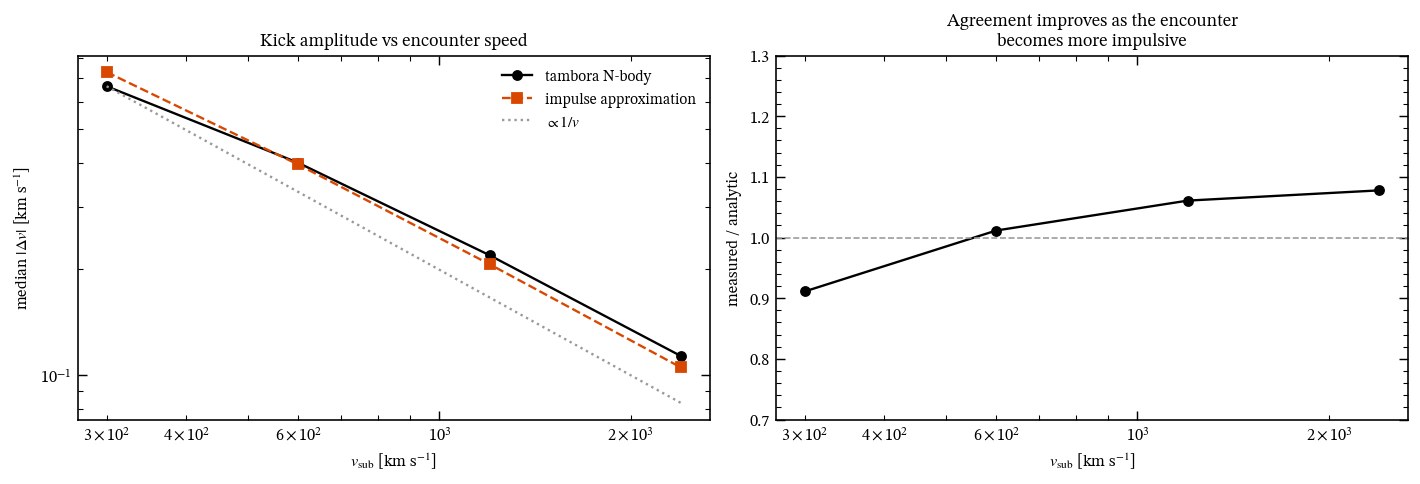

In [10]:
vs, mm, aa = np.array(rows).T

fig, ax = plt.subplots(1, 2, figsize=(11.0, 3.8))
ax[0].loglog(vs, mm, "o-", c="k", ms=5, label="tambora N-body")
ax[0].loglog(vs, aa, "s--", c="#d94801", ms=5, label="impulse approximation")
ax[0].loglog(vs, mm[0] * vs[0] / vs, ":", c="0.6", label=r"$\propto 1/v$")
ax[0].set_xlabel(r"$v_{\rm sub}$ [km s$^{-1}$]")
ax[0].set_ylabel(r"median $|\Delta v|$ [km s$^{-1}$]")
ax[0].set_title("Kick amplitude vs encounter speed")
ax[0].legend()

ax[1].semilogx(vs, mm / aa, "o-", c="k", ms=5)
ax[1].axhline(1.0, c="0.6", lw=0.9, ls="--")
ax[1].set_xlabel(r"$v_{\rm sub}$ [km s$^{-1}$]")
ax[1].set_ylabel("measured / analytic")
ax[1].set_ylim(0.7, 1.3)
ax[1].set_title("Agreement improves as the encounter\nbecomes more impulsive")
fig.tight_layout()
plt.show()

The N-body result follows $1/v$ over a factor of eight in speed, and the ratio
to the analytic prediction converges towards unity as the encounter gets
faster — exactly as it should, because the impulse approximation's central
assumption is that the stars do not move while the perturber goes by.

At 300 km/s the stream moves a noticeable distance during the encounter and the
approximation is a few per cent low; by 2400 km/s it is essentially exact.

## 8. The observable signature

The kick is instantaneous; the *signature* takes time to develop. Stars kicked
towards the perturber's path converge and those kicked away diverge, so over
roughly a dynamical time the velocity perturbation is converted into a density
perturbation: an under-dense gap flanked by over-dense caustics.

> **This is a different measurement from section 4.** There we differenced the
> two runs 20 Myr after closest approach to isolate the *impulse*. Here we run
> for 300 Myr, during which the perturber is still (weakly) pulling on the whole
> stream from a distance. The late-time velocity difference is therefore not the
> impulse, and should not be compared with it.

In [11]:
t0 = time.time()
ctrl_l, imp_l = run_pair(V_SUB, t_end=T_POST, dt=DT, dt_out=0.01)
print(f"{time.time() - t0:.0f} s")

Pc, Vc = ctrl_l.stream.pos(t=-1), ctrl_l.stream.vel(t=-1)
Pi, Vi = imp_l.stream.pos(t=-1), imp_l.stream.vel(t=-1)

# A stream-aligned coordinate, defined on the CONTROL run so both are measured
# on the same axis.
prog_f = Pc[bound].mean(0)
u_f = np.linalg.svd(Pc[unbound] - Pc[unbound].mean(0))[2][0]
s_c = (Pc[unbound] - prog_f) @ u_f
s_i = (Pi[unbound] - prog_f) @ u_f
dv_l = np.linalg.norm((Vi - Vc)[unbound], axis=1)

# Where the perturbation actually landed: the kick-weighted centroid. The launch
# geometry cannot tell us this, because the stream shears over 300 Myr.
s_hit = np.average(s_c, weights=dv_l)
print(f"kick-weighted impact centroid: s = {s_hit:+.2f} kpc")

67 s
kick-weighted impact centroid: s = +0.88 kpc


### Three profiles along the stream

Density is the usual diagnostic, but it is not the only one. Because the
perturber imparts a *coherent* velocity pattern, the mean velocity along the
stream picks up a characteristic wiggle, and the local dispersion rises where
stars on different orbits have been folded together.

We measure the dispersion **perpendicular to the stream axis**. The along-stream
component is dominated by the stream's own velocity gradient, which would swamp
the signal.

In [12]:
bins = np.linspace(np.percentile(s_c, 1), np.percentile(s_c, 99), 40)
ctr = 0.5 * (bins[1:] + bins[:-1])


def profiles(s_vals, V):
    """Counts, mean along-stream velocity, and perpendicular dispersion."""
    n, v_par, sig_perp = [], [], []
    for lo, hi in zip(bins[:-1], bins[1:]):
        sel = (s_vals >= lo) & (s_vals < hi)
        n.append(sel.sum())
        if sel.sum() > 12:
            vv = V[unbound][sel]
            par = vv @ u_f
            perp = vv - np.outer(par, u_f)
            v_par.append(par.mean())
            sig_perp.append(
                np.sqrt(np.mean(np.sum((perp - perp.mean(0)) ** 2, axis=1)))
            )
        else:
            v_par.append(np.nan)
            sig_perp.append(np.nan)
    return np.array(n), np.array(v_par), np.array(sig_perp)


n_c, vpar_c, sig_c = profiles(s_c, Vc)
n_i, vpar_i, sig_i = profiles(s_i, Vi)
ratio = np.where(n_c > 8, n_i / np.maximum(n_c, 1), np.nan)

print(f"deepest point of the gap : {np.nanmin(ratio):.2f} "
      f"at s = {ctr[np.nanargmin(ratio)]:+.2f} kpc")
print(f"largest mean-velocity shift : {np.nanmax(np.abs(vpar_i - vpar_c)):.2f} km/s")
print(f"largest dispersion excess   : {np.nanmax(sig_i - sig_c):+.2f} km/s")

deepest point of the gap : 0.21 at s = -0.39 kpc
largest mean-velocity shift : 2.28 km/s
largest dispersion excess   : +3.45 km/s


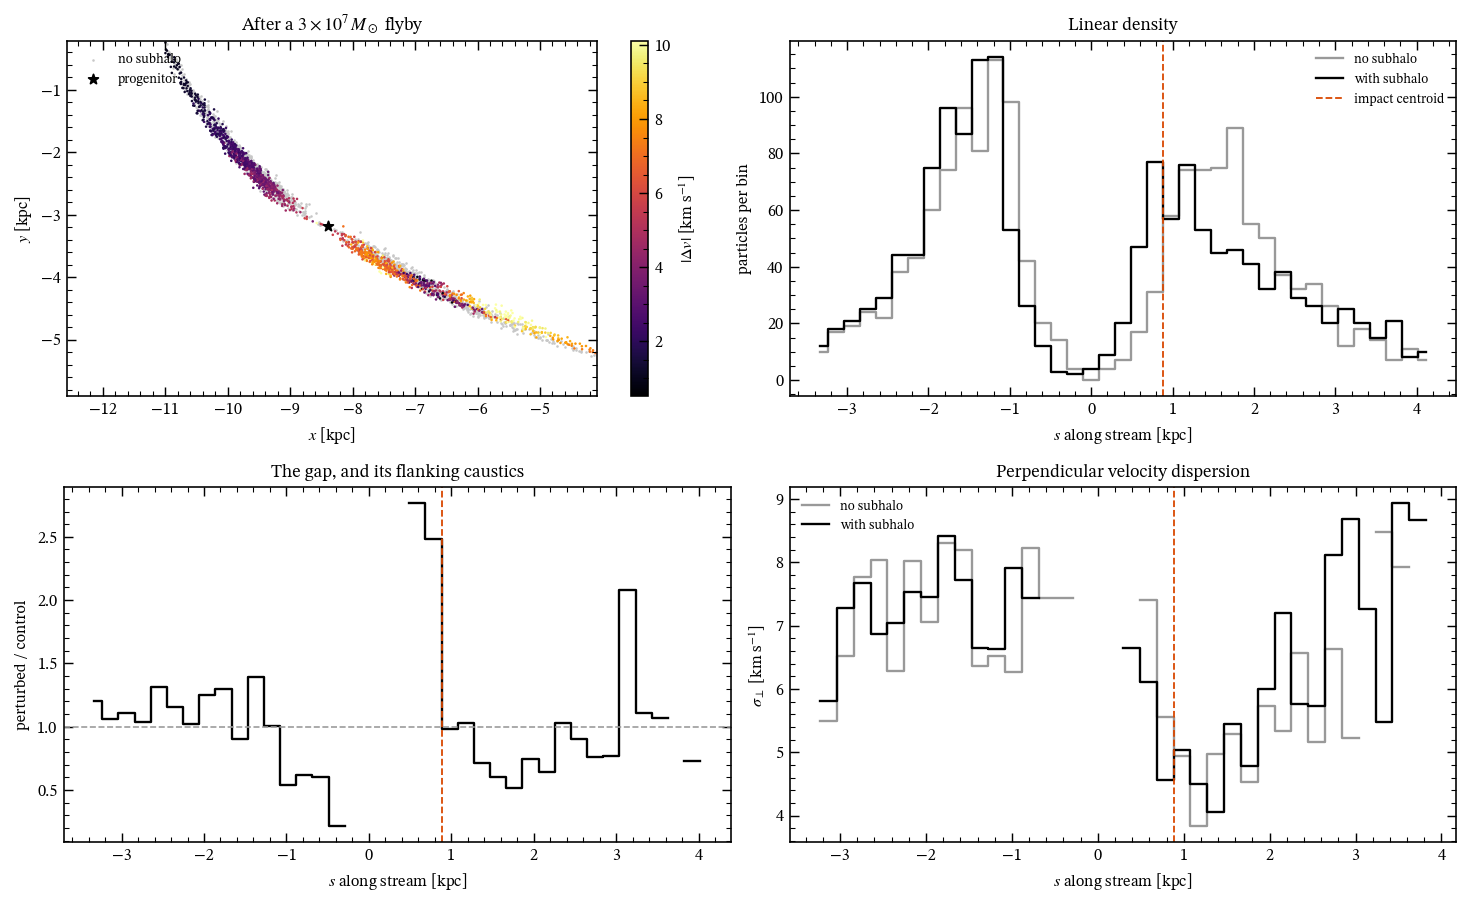

In [13]:
fig, ax = plt.subplots(2, 2, figsize=(11.4, 7.0))

a = ax[0, 0]
a.scatter(Pc[unbound, 0], Pc[unbound, 1], s=2, lw=0, c="0.78",
          label="no subhalo", rasterized=True)
sc_pts = a.scatter(Pi[unbound, 0], Pi[unbound, 1], s=2, lw=0, c=dv_l,
                   cmap="inferno", vmax=np.percentile(dv_l, 98), rasterized=True)
a.scatter(*prog_f[:2], s=32, c="k", marker="*", zorder=5, label="progenitor")
xs, ys = Pi[unbound, 0], Pi[unbound, 1]
xw, yw = np.ptp(xs) * 1.12, np.ptp(ys) * 1.06
a.set_xlim(xs.mean() - xw / 2, xs.mean() + xw / 2)
a.set_ylim(ys.mean() - yw / 2, ys.mean() + yw / 2)
a.set_box_aspect(yw / xw)
a.set_xlabel("$x$ [kpc]")
a.set_ylabel("$y$ [kpc]")
a.set_title(rf"After a ${M_SUB / 1e7:.0f}\times10^7\,M_\odot$ flyby")
a.legend(loc="upper left", fontsize=7.5)
plt.colorbar(sc_pts, ax=a, label=r"$|\Delta v|$ [km s$^{-1}$]")

a = ax[0, 1]
a.step(ctr, n_c, where="mid", c="0.6", label="no subhalo")
a.step(ctr, n_i, where="mid", c="k", label="with subhalo")
a.axvline(s_hit, c="#d94801", lw=1.0, ls="--", label="impact centroid")
a.set_xlabel("$s$ along stream [kpc]")
a.set_ylabel("particles per bin")
a.set_title("Linear density")
a.legend(fontsize=7.5)

a = ax[1, 0]
a.step(ctr, ratio, where="mid", c="k")
a.axhline(1.0, c="0.6", lw=0.9, ls="--")
a.axvline(s_hit, c="#d94801", lw=1.0, ls="--")
a.set_xlabel("$s$ along stream [kpc]")
a.set_ylabel("perturbed / control")
a.set_title("The gap, and its flanking caustics")

a = ax[1, 1]
a.step(ctr, sig_c, where="mid", c="0.6", label="no subhalo")
a.step(ctr, sig_i, where="mid", c="k", label="with subhalo")
a.axvline(s_hit, c="#d94801", lw=1.0, ls="--")
a.set_xlabel("$s$ along stream [kpc]")
a.set_ylabel(r"$\sigma_\perp$ [km s$^{-1}$]")
a.set_title("Perpendicular velocity dispersion")
a.legend(fontsize=7.5)

fig.tight_layout()
plt.show()

The density panel shows the classic pair: a deficit where stars have been
swept out, immediately flanked by an excess where they have piled up. The
dispersion panel shows the kinematic counterpart — the perturbed stream is
locally hotter, because stars that used to be on neighbouring orbits have been
given different kicks and are now crossing.

The dispersion signal is noisier than the density signal, and that is
characteristic rather than a defect of this particular run: density is a count,
while dispersion is a second moment, so for the same number of stars it carries
considerably more Poisson noise. In real data the density gap is usually found
first and the kinematic signature used to confirm it.

### Measuring the width with galpy

Rather than binning by hand, you can fit the perturbed and unperturbed streams
with `StreamTrack` and read the width straight off the fitted covariance — the
machinery from
[notebook 06](06-stream-track.ipynb), now used as a gap-detection tool. The
advantage is that it measures the width *perpendicular to the fitted track*
rather than to a straight axis, which matters once the track bends.

## 9. Watch the gap open

The gap is not present at the moment of impact — it develops as the velocity
perturbation shears into a density perturbation. Animating the two runs side by
side makes the causal sequence obvious.

31 frames, 0.3 MB


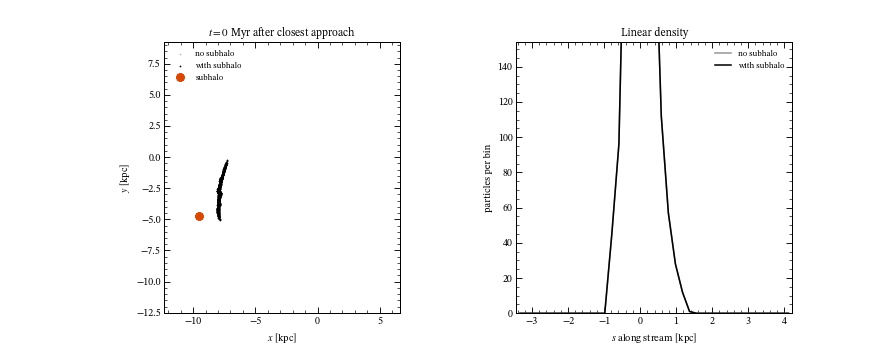

In [14]:
from matplotlib.animation import FuncAnimation, PillowWriter  # noqa: E402
from IPython.display import Image  # noqa: E402
from PIL import Image as PILImage, ImageSequence  # noqa: E402

Pc_all = ctrl_l.stream.pos()
Pi_all = imp_l.stream.pos()
times = ctrl_l.times
sub_track = imp_l.sub.pos()

fig, (a0, a1) = plt.subplots(1, 2, figsize=(11.0, 4.4),
                             gridspec_kw={"width_ratios": [1.25, 1]})

sc_c = a0.scatter([], [], s=2.5, lw=0, c="0.75", label="no subhalo")
sc_i = a0.scatter([], [], s=2.5, lw=0, c="k", label="with subhalo")
(sub_pt,) = a0.plot([], [], "o", c="#d94801", ms=7, label="subhalo")
xs, ys = Pi_all[:, unbound, 0], Pi_all[:, unbound, 1]
a0.set_xlim(xs.min() - 0.5, xs.max() + 0.5)
a0.set_ylim(ys.min() - 0.5, ys.max() + 0.5)
a0.set_aspect("equal")
a0.set_xlabel("$x$ [kpc]")
a0.set_ylabel("$y$ [kpc]")
a0.legend(loc="upper left", fontsize=7.5)
ttl = a0.set_title("")

(line_c,) = a1.plot([], [], c="0.6", lw=1.4, label="no subhalo")
(line_i,) = a1.plot([], [], c="k", lw=1.4, label="with subhalo")
a1.set_xlim(bins[0], bins[-1])
a1.set_ylim(0, max(n_c.max(), n_i.max()) * 1.35)
a1.set_xlabel("$s$ along stream [kpc]")
a1.set_ylabel("particles per bin")
a1.set_title("Linear density")
a1.legend(loc="upper right", fontsize=7.5)


def update(k):
    pc, pi = Pc_all[k][unbound], Pi_all[k][unbound]
    sc_c.set_offsets(pc[:, :2])
    sc_i.set_offsets(pi[:, :2])
    sub_pt.set_data([sub_track[k, 0, 0]], [sub_track[k, 0, 1]])
    pf_k = Pc_all[k][bound].mean(0)
    hc_k, _ = np.histogram((pc - pf_k) @ u_f, bins=bins)
    hi_k, _ = np.histogram((pi - pf_k) @ u_f, bins=bins)
    line_c.set_data(ctr, hc_k)
    line_i.set_data(ctr, hi_k)
    ttl.set_text(f"$t = {times[k] * 1000:.0f}$ Myr after closest approach")
    return sc_c, sc_i, sub_pt, line_c, line_i, ttl


anim = FuncAnimation(fig, update, frames=range(len(times)), blit=False)
anim.save("stream_gap.gif", writer=PillowWriter(fps=6), dpi=80)
plt.close(fig)

_src = PILImage.open("stream_gap.gif")
_fr = [f.copy().convert("RGB").quantize(colors=96, method=PILImage.MEDIANCUT)
       for f in ImageSequence.Iterator(_src)]
_fr[0].save("stream_gap.gif", save_all=True, append_images=_fr[1:],
            duration=166, loop=0, optimize=True)
print(f"{len(_fr)} frames, "
      f"{__import__('os').path.getsize('stream_gap.gif') / 1e6:.1f} MB")

Image(filename="stream_gap.gif")

The subhalo (orange) crosses in the first couple of frames and is gone. Nothing
visible happens for tens of megayears — and then the density profile slowly
develops its notch, long after the perturber has left. That delay is why a gap
tells you about an encounter that happened in the past, and why gap *widths*
encode the time since impact.

## Caveats worth carrying forward

- **A single flyby is the easy case.** Real streams are hit repeatedly by a
  spectrum of subhalo masses, and the resulting density power spectrum — not any
  individual gap — is what constrains dark matter.
- **Baryonic perturbers do this too.** Giant molecular clouds and the Galactic
  bar produce comparable features, so a gap is not by itself evidence of dark
  substructure.
- **Resolution.** A gap is a deficit against a Poisson background. With
  $N \sim 10^3$ particles per tail the noise is comparable to the signal, which
  is why this notebook uses 8000 particles and still shows a visibly ragged
  density profile. Convergence-test any gap you intend to quote — see
  [Reliable N-body simulations](../guide/reliable-nbody.md#demonstrating-convergence).

## Where to go next

- [Stream tracks and observables](06-stream-track.ipynb) — fit the perturbed
  stream and look for the gap in observable coordinates.
- [Tidal stripping](05-tidal-stripping.ipynb) — where the stream came from.

Things to try:

- Vary `M_SUB` from $10^6$ to $10^8$ and find the mass at which the gap becomes
  detectable above the Poisson noise.
- Vary `B_IMP`. The kick scales roughly as $b/(b^2 + r_s^2)$, so it peaks near
  $b \sim r_s$ and falls off both ways.
- Set `kernel=1` (the default) instead of `0` and re-run section 6. The
  agreement degrades, because the analytic formula assumes a Plummer profile.